In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import joblib

In [2]:
df = pd.read_excel(
    "Data_Model_IoTMLCQ_2024.xlsx"
)

print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(4383, 28)


,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable


In [3]:
X = df[[
    'Temperature (°C)',
    'Dissolved Oxygen (mg/L)',
    'pH',
    'Turbidity (NTU)',
    'hour'
]]

y = df['Health Status']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("Training Data:", len(X_train))
print("Testing Data :", len(X_test))

Training Data: 3506
Testing Data : 877


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [6]:
lr = LogisticRegression(

    random_state=42,

    max_iter=1000

)

lr.fit(
    X_train_scaled,
    y_train
)

print(
    "Logistic Regression Training Finished"
)

Logistic Regression Training Finished


In [7]:
lr_pred = lr.predict(
    X_test_scaled
)

In [8]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Accuracy:",
    round(
        lr_accuracy * 100,
        4
    ),
    "%"
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Accuracy: 99.7719 %
              precision    recall  f1-score   support

     At Risk       0.99      1.00      0.99       138
      Stable       1.00      1.00      1.00       739

    accuracy                           1.00       877
   macro avg       0.99      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [9]:
lr_precision = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

evaluation_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]

})

evaluation_table

,Metric,Value
0,Accuracy,0.997719
1,Precision,0.997752
2,Recall,0.997719
3,F1 Score,0.997726


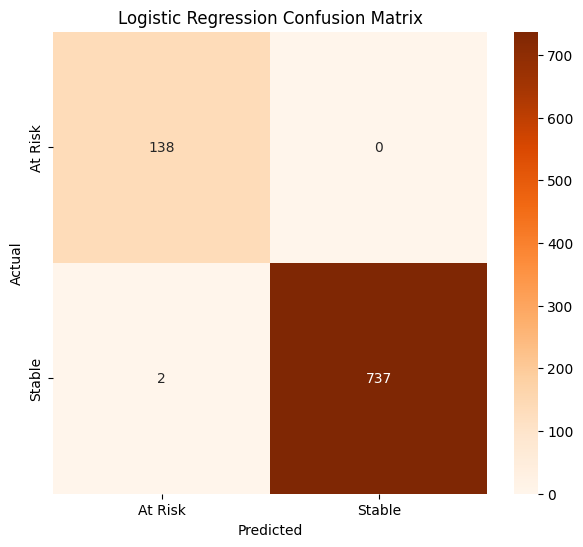

In [10]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [11]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lr.coef_[0]

})

importance = importance.sort_values(
    "Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
3,Turbidity (NTU),2.190840
4,hour,-0.261755
2,pH,-1.044800
1,Dissolved Oxygen (mg/L),-1.299906
0,Temperature (°C),-5.060447


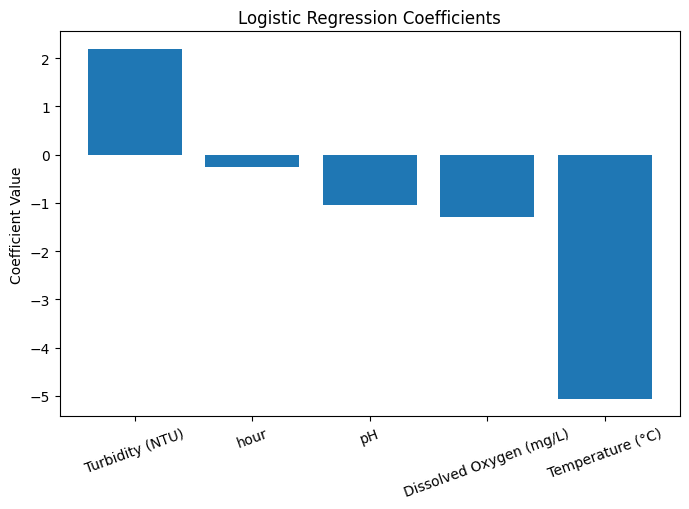

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Coefficient"]
)

plt.title(
    "Logistic Regression Coefficients"
)

plt.ylabel(
    "Coefficient Value"
)

plt.xticks(rotation=20)

plt.show()

In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))

])

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=cv,

    scoring='accuracy'

)

cv_table = pd.DataFrame({

    "Fold":[
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5"
    ],

    "Accuracy":scores

})

cv_table

,Fold,Accuracy
0,Fold 1,0.995439
1,Fold 2,0.997719
2,Fold 3,1.000000
3,Fold 4,0.995434
4,Fold 5,1.000000


In [14]:
print(
    "Mean Accuracy:",
    scores.mean()
)

Mean Accuracy: 0.9977184569646418


In [15]:
joblib.dump(
    lr,
    "aquaagent_logistic_regression.pkl"
)

print(
    "Model Saved"
)

Model Saved


In [16]:
sample = pd.DataFrame([{

    'Temperature (°C)':31,
    'Dissolved Oxygen (mg/L)':4.2,
    'pH':8.5,
    'Turbidity (NTU)':15,
    'hour':14

}])

sample_scaled = scaler.transform(
    sample
)

prediction = lr.predict(
    sample_scaled
)

print(
    "Sample Prediction:",
    prediction
)

Sample Prediction: ['Stable']
